# Рахимьянов Альберт, ЕТ-128, "Иерархическая кластеризация"

## Задание
1. Выполните иерархическую кластеризацию набора данных, используя различные меры схожести: Single linkage, Complete linkage, Group average, расстояние Уорда (Ward). Выполните визуализацию полученных результатов в виде дендрограмм.
2. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
- формулировка задания;
- гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
- рисунки с результатами визуализации;
- пояснения, раскрывающие смысл полученных результатов.

In [60]:
# Библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.datasets import make_blobs, make_moons
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

np.random.seed(43)

In [133]:
# Создание набора данных
# Кластер 1 - плотный
X1, _ = make_blobs(n_samples=20, centers=[[2, 2]], cluster_std=0.3, random_state=42)

# Кластер 2 - вытянутый
X2, _ = make_blobs(n_samples=54, centers=[[4, 4.8]], cluster_std=0.72, random_state=42)
X2 = X2 @ np.array([[2, 0.4], [0.5, 1]])

# Кластер 3 - разряженный
X3, _ = make_blobs(n_samples=40, centers=[[9, 3]], cluster_std=0.9, random_state=42)

# Добавляем шумовые точки
X_noise = np.random.uniform(low=0, high=10, size=(5, 2))

# Объединяем все данные
X = np.vstack([X1, X2, X3, X_noise])
df = pd.DataFrame(X, columns=['X', 'Y'])
print(f"Размерность данных: {X.shape}")

Размерность данных: (119, 2)


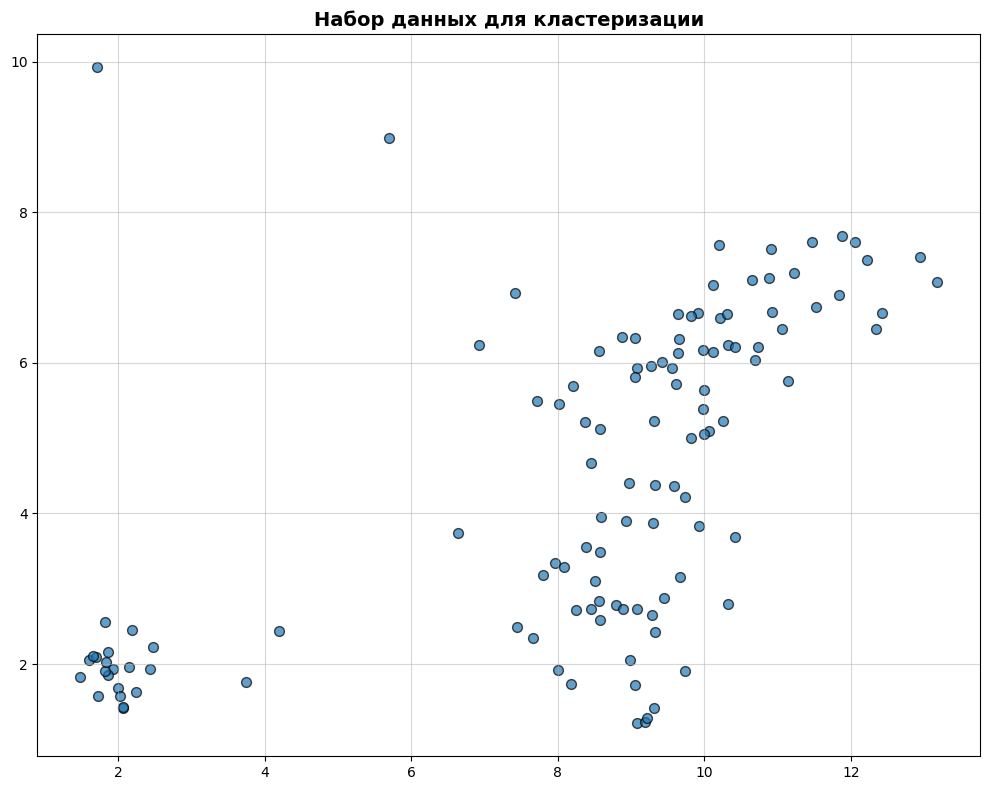

In [134]:
# Визуализация исходных данных
plt.figure(figsize=(10, 8))
plt.scatter(df['X'], df['Y'], s=50, alpha=0.7, edgecolors='black', linewidth=1)
plt.title('Набор данных для кластеризации', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [120]:
# Определяем методы кластеризации
methods = {
    'single': 'Single linkage (ближайший сосед)',
    'complete': 'Complete linkage (дальний сосед)',
    'average': 'Group average (среднее расстояние)',
    'ward': 'Ward (минимум дисперсии)'
}

distance_matrix = pdist(X)

# Кластеризация
linkage_results = {}
for method, description in methods.items():
    linkage_results[method] = linkage(X, method=method, metric='euclidean')


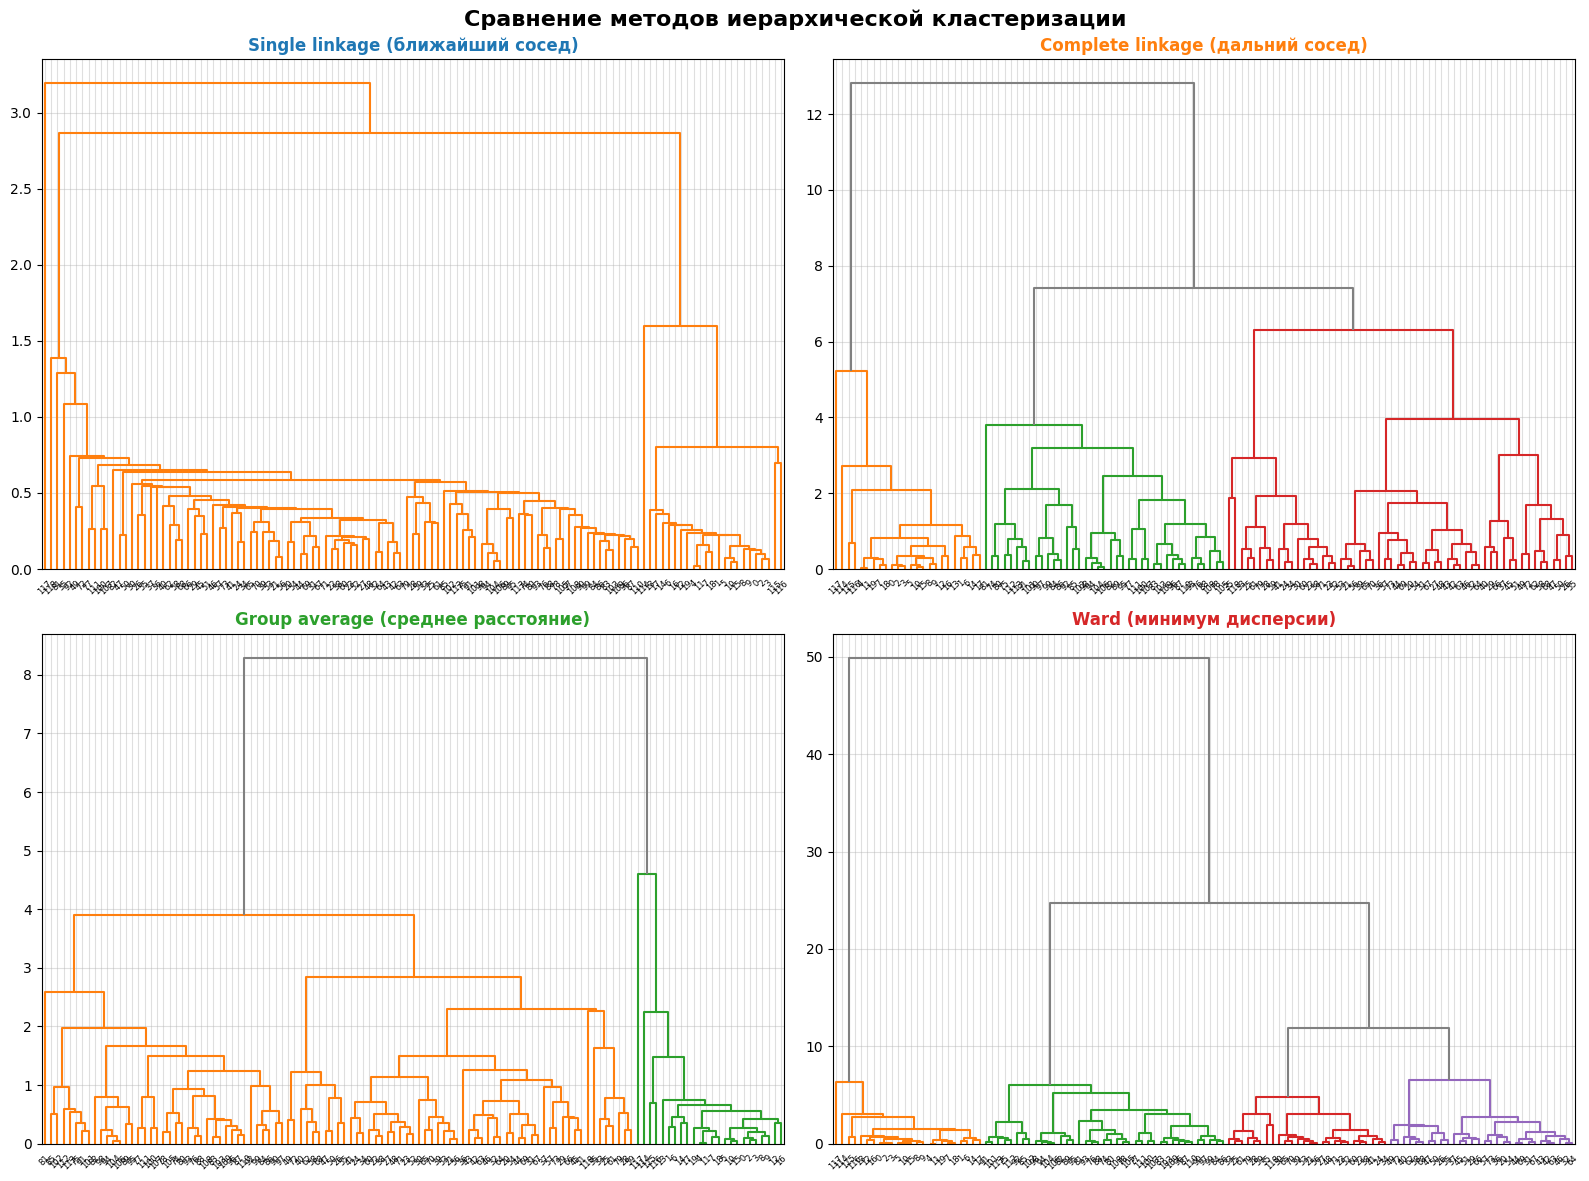

In [132]:
# Визуализируем результаты
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (method, description) in enumerate(methods.items()):
    # Построение дендрограммы
    dendrogram(
        linkage_results[method],
        ax=axes[idx],
        leaf_rotation=45,
        leaf_font_size=6,
        color_threshold=7,
        above_threshold_color='gray'
    )

    axes[idx].set_title(f'{description}', fontsize=12, fontweight='bold', color=colors[idx])
    axes[idx].grid(True, alpha=0.4)

plt.suptitle('Сравнение методов иерархической кластеризации', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

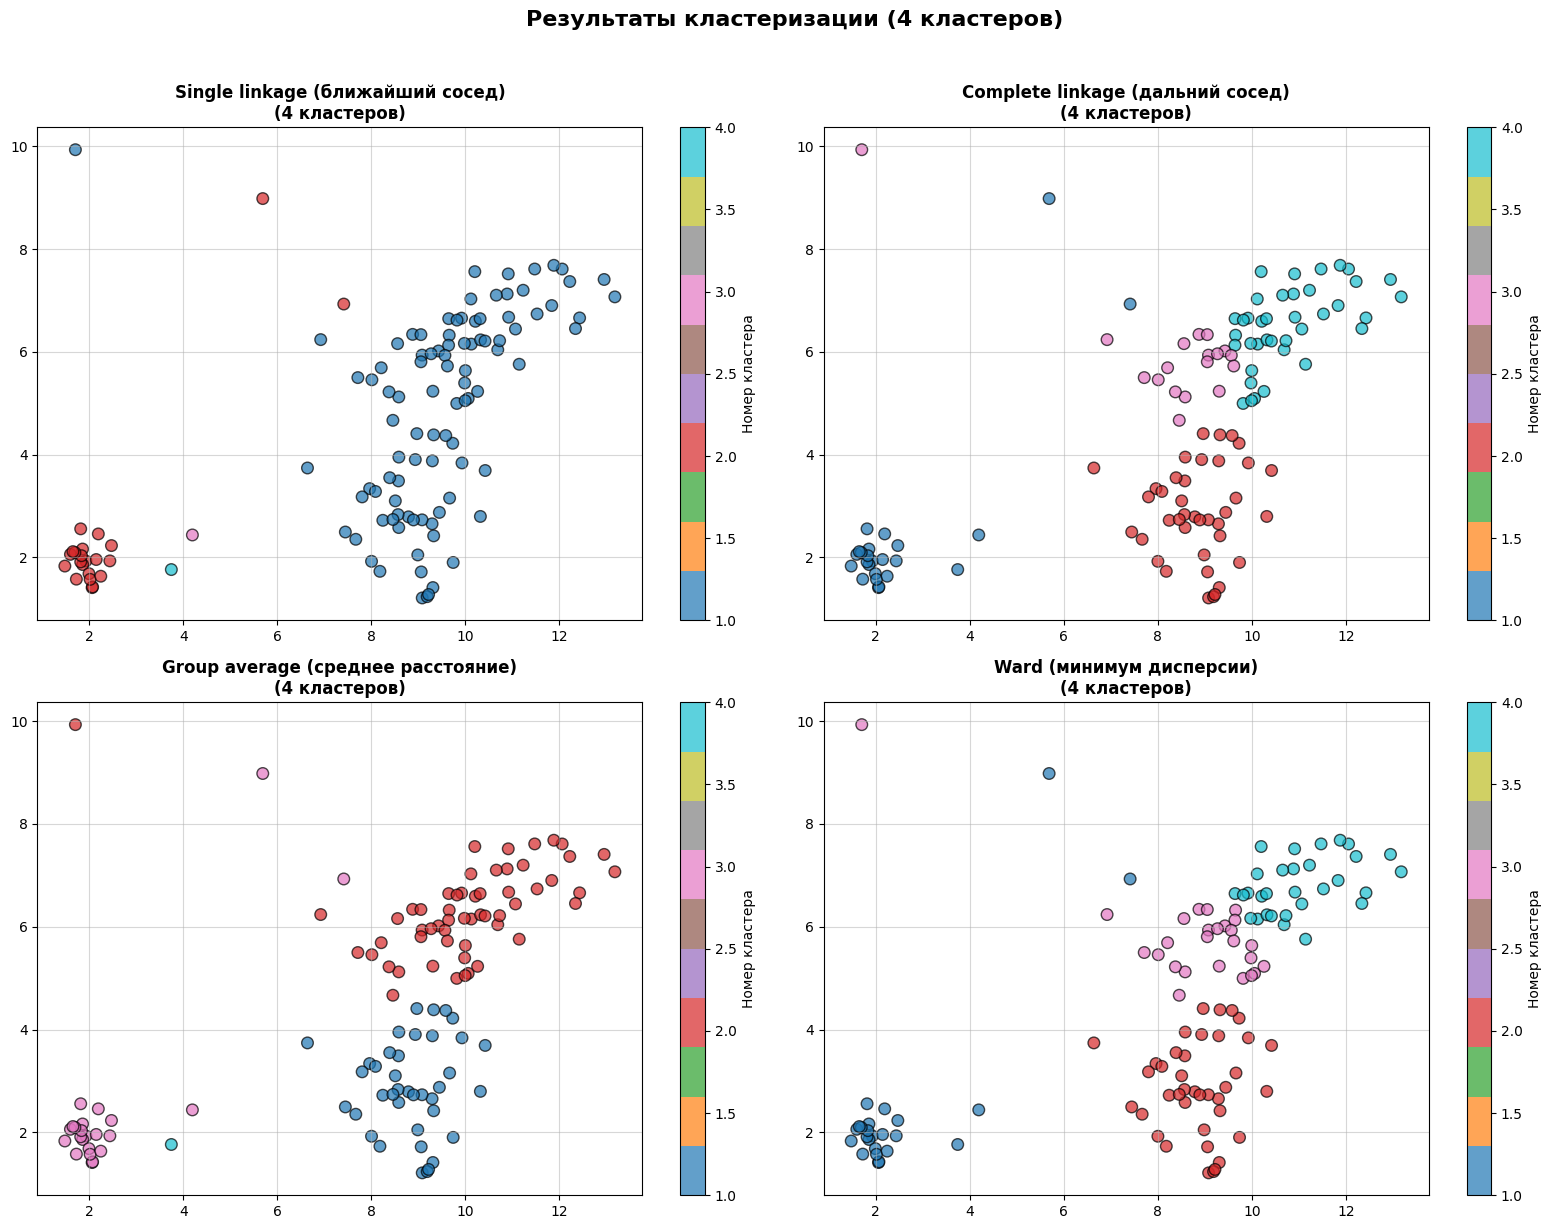

In [136]:
# Определяем количество кластеров
n_clusters = 4

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (method, description) in enumerate(methods.items()):
    clusters = fcluster(linkage_results[method], n_clusters, criterion='maxclust')

    # Визуализация
    scatter = axes[idx].scatter(df['X'], df['Y'], c=clusters, cmap='tab10',
                                s=70, alpha=0.7, edgecolors='black', linewidth=1)

    axes[idx].set_title(f'{description}\n({n_clusters} кластеров)', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.5)

    plt.colorbar(scatter, ax=axes[idx], label='Номер кластера')

plt.suptitle(f'Результаты кластеризации ({n_clusters} кластеров)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()